# <font color="#0099CC">**Extras: ampliación predictiva y variantes de fairness**</font>

El notebook principal resuelve el entregable obligatorio del taller: una red neuronal confiable con un conjunto reducido de variables, aprendizaje justo, curva de Pareto e incertidumbre. Ese flujo se mantiene separado porque es el que permite defender con claridad los requisitos de confiabilidad.

Este notebook estudia extensiones sobre ese punto de partida. La pregunta ya no es solo si el modelo puede ser justo e interpretable, sino qué ocurre cuando se amplía la información disponible y se prueban modelos especialmente fuertes para datos tabulares.

El recorrido sigue una lógica incremental: primero se comparan los modelos del MVP con 12 variables, después se incorpora una versión extendida de 42 variables de la tabla principal, más tarde se construye una representación relacional completa y finalmente se evalúan LightGBM, XGBoost y una variante de coste FAIR cuadrática. Así el evaluador puede separar tres efectos: más variables, más fuentes de datos y otra familia de modelo.

## <font color="#0099CC">**0. Contrato experimental**</font>

Los extras se ejecutan fuera del camino oficial del MVP. Todos los artefactos de este notebook se escriben en `results/extras/<run_id>/`; no se sobrescriben tablas, figuras ni modelos del notebook principal. Esta separación permite experimentar sin contaminar la evidencia del entregable obligatorio.

La configuración fija rutas, semillas y validación cruzada. Para LightGBM y XGBoost se usa evaluación *out-of-fold*: cada predicción de entrenamiento se obtiene con un modelo que no vio esa fila durante el ajuste. Esta decisión evita presentar una métrica optimista calculada sobre el propio entrenamiento.

La comparación final distingue entre resultados ejecutados en este notebook, artefactos ya generados dentro del proyecto y experimentos pendientes. Cuando un experimento no se ha ejecutado, se marca como pendiente; no se duplica ni se sustituye por una referencia informal.

In [1]:
from pathlib import Path
import os
import random
import sys
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "raw"
RUN_ID = None
SEED = 42
N_FOLDS = 5
N_SEEDS = 1

RUN_RELATIONAL_FEATURES = True
RUN_LIGHTGBM = True
RUN_XGBOOST = False

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
warnings.filterwarnings("ignore", category=FutureWarning)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("RUN_RELATIONAL_FEATURES:", RUN_RELATIONAL_FEATURES)
print("RUN_LIGHTGBM:", RUN_LIGHTGBM)
print("RUN_XGBOOST:", RUN_XGBOOST)

PROJECT_ROOT: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani
DATA_RAW: c:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\data\raw
RUN_RELATIONAL_FEATURES: True
RUN_LIGHTGBM: True
RUN_XGBOOST: False


In [2]:
import sys
import subprocess
from pathlib import Path

# Dependencias que el paquete necesita al importarse desde el notebook.
# Si ya están instaladas, no hace nada.
missing_packages = []

for package_name, pip_name in [
    ("fairlearn", "fairlearn>=0.10.0"),
    ("lightgbm", "lightgbm>=4.0.0"),
    ("xgboost", "xgboost>=2.0.0"),
]:
    try:
        __import__(package_name)
    except ModuleNotFoundError:
        missing_packages.append(pip_name)

if missing_packages:
    print("Instalando dependencias faltantes:", missing_packages)
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_packages,
    ])

from src.trustworthy_credit.relational_features import (
    RelationalDataLoader,
    RelationalFeatureConfig,
    RelationalFeaturePipeline,
)
from src.trustworthy_credit.gbm_experiments import (
    FeatureImportanceReporter,
    GBMArtifactPaths,
    GBMExperimentConfig,
    LightGBMOOFRunner,
    XGBoostOOFRunner,
    write_extras_manifest,
)

rel_config = RelationalFeatureConfig(
    raw_data_dir=DATA_RAW,
    include_sensitive_feature=True,
)

gbm_config = GBMExperimentConfig(
    n_folds=N_FOLDS,
    seed=SEED,
    n_seeds=N_SEEDS,
    early_stopping_rounds=200,
    log_period=200,
)

paths = GBMArtifactPaths(project_root=PROJECT_ROOT, run_id=RUN_ID)
reporter = FeatureImportanceReporter()

assert paths.tables_dir != PROJECT_ROOT / "results" / "tables"
assert str(paths.run_dir).endswith(str(Path("results") / "extras" / paths.run_id))

paths.create()

print("EXTRAS_RUN_ID:", paths.run_id)
print("EXTRAS_RUN_DIR:", paths.run_dir)
print("TABLES:", paths.tables_dir)
print("PREDICTIONS:", paths.predictions_dir)
print("FIGURES:", paths.figures_dir)

EXTRAS_RUN_ID: 20260625_092941
EXTRAS_RUN_DIR: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\extras\20260625_092941
TABLES: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\extras\20260625_092941\tables
PREDICTIONS: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\extras\20260625_092941\predictions
FIGURES: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\taller-redes-confiables-dani\results\extras\20260625_092941\figures


## <font color="#0099CC">**1. Disponibilidad de datos**</font>

El MVP solo necesita `application_train.csv`, porque su objetivo es controlar un flujo confiable sobre un conjunto reducido. Los extras predictivos requieren más información: solicitudes oficiales de test, créditos registrados en bureau, balances mensuales, solicitudes anteriores, pagos, saldos POS y uso de tarjeta.

Cada fuente describe una parte distinta del comportamiento financiero del cliente. Antes de transformar nada, el notebook comprueba que todas las tablas existen. Si falta una fuente relacional, el experimento se detiene porque la matriz final ya no representaría el escenario completo que se quiere evaluar.

In [3]:
loader = RelationalDataLoader(DATA_RAW)
file_status = []
for file_name in loader.expected_files:
    file_path = DATA_RAW / file_name
    file_status.append(
        {
            "file": file_name,
            "exists": file_path.exists(),
            "size_mb": round(file_path.stat().st_size / 1e6, 1) if file_path.exists() else np.nan,
        }
    )
file_status = pd.DataFrame(file_status)
display(file_status)

if not file_status["exists"].all():
    missing = file_status.loc[~file_status["exists"], "file"].tolist()
    raise FileNotFoundError(f"Faltan CSV para el extra relacional: {missing}")

,file,exists,size_mb
0,application_train.csv,True,166.1
1,application_test.csv,True,26.6
2,bureau.csv,True,170.0
3,bureau_balance.csv,True,375.6
4,previous_application.csv,True,405.0
5,installments_payments.csv,True,723.1
6,POS_CASH_balance.csv,True,392.7
7,credit_card_balance.csv,True,424.6


## <font color="#0099CC">**2. Del conjunto compacto a 42 variables**</font>

Antes de usar tablas relacionales conviene medir un salto intermedio: ampliar la información de la tabla principal sin cambiar todavía la fuente de datos. Esta sección separa dos efectos que, si se mezclan, serían difíciles de interpretar: por un lado, el efecto de dar más variables al modelo; por otro, el efecto de incorporar historial relacional completo.

El conjunto compacto de 12 variables representa la versión controlada de la práctica: importes básicos, edad, ratio de endeudamiento, las tres variables `EXT_SOURCE` y sus máscaras de ausencia. Es un espacio reducido y defendible para estudiar leakage, fairness e incertidumbre. La versión de 42 variables sigue usando únicamente `application_train`, pero añade más señales de la solicitud: situación laboral, vivienda, composición familiar, antigüedad de registros, consultas a bureau y variables sociales simples.

La lectura de este bloque es deliberadamente acotada. Si el paso de 12 a 42 mejora, parte del límite predictivo venía de la representación inicial. Si la mejora es moderada, el siguiente salto razonable no es seguir añadiendo columnas de la misma tabla, sino incorporar el historial completo del cliente mediante agregaciones relacionales.

In [ ]:
MVP_12_FEATURES = [
    "CODE_GENDER",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AGE_YEARS",
    "DEBT_RATIO",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_1_MISSING",
    "EXT_SOURCE_2_MISSING",
    "EXT_SOURCE_3_MISSING",
]

MARCO_42_FEATURES = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_INCOME_TYPE",
    "REGION_RATING_CLIENT_W_CITY",
    "AMT_GOODS_PRICE",
    "FLAG_OWN_CAR",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_REGISTRATION",
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "OWN_CAR_AGE",
    "REG_CITY_NOT_WORK_CITY",
]

assert len(MVP_12_FEATURES) == 12
assert len(MARCO_42_FEATURES) == 42
assert "TARGET" not in MVP_12_FEATURES
assert "TARGET" not in MARCO_42_FEATURES
assert "SK_ID_CURR" not in MVP_12_FEATURES
assert "SK_ID_CURR" not in MARCO_42_FEATURES


def feature_family(feature_name: str) -> str:
    if feature_name.startswith("EXT_SOURCE"):
        return "scores externos"
    if feature_name.startswith("AMT_") or feature_name == "DEBT_RATIO":
        return "financiera"
    if feature_name.startswith("DAYS_") or feature_name == "AGE_YEARS":
        return "temporal"
    if feature_name.startswith("NAME_") or feature_name in {"CODE_GENDER", "OCCUPATION_TYPE", "ORGANIZATION_TYPE", "FLAG_OWN_CAR"}:
        return "categórica/binaria"
    if feature_name.startswith("CNT_"):
        return "composición familiar"
    if feature_name.startswith("FLAG_") or feature_name.startswith("REG_"):
        return "contacto y registro"
    if feature_name.startswith("DEF_") or feature_name.startswith("OBS_"):
        return "entorno social"
    if feature_name.startswith("AMT_REQ_CREDIT_BUREAU"):
        return "consultas bureau"
    if feature_name == "OWN_CAR_AGE":
        return "activo y antigüedad"
    return "otra"


feature_catalog = pd.concat(
    [
        pd.DataFrame({"conjunto": "12 features compactas", "feature": MVP_12_FEATURES}),
        pd.DataFrame({"conjunto": "42 features application_train", "feature": MARCO_42_FEATURES}),
    ],
    ignore_index=True,
)
feature_catalog["familia"] = feature_catalog["feature"].map(feature_family)

application_columns = set(pd.read_csv(DATA_RAW / "application_train.csv", nrows=0).columns)
missing_42_raw = sorted(set(MARCO_42_FEATURES) - application_columns)
assert not missing_42_raw, f"Faltan columnas de application_train en el catálogo de 42 features: {missing_42_raw}"

feature_set_summary = pd.DataFrame(
    [
        {
            "conjunto": "12 features compactas",
            "n_features": len(MVP_12_FEATURES),
            "fuente_datos": "application_train con ingeniería mínima",
            "uso_en_el_flujo": "referencia controlada para base y FAIR",
        },
        {
            "conjunto": "42 features application_train",
            "n_features": len(MARCO_42_FEATURES),
            "fuente_datos": "application_train sin tablas relacionales",
            "uso_en_el_flujo": "medir si ampliar variables ya eleva el techo predictivo",
        },
    ]
)

feature_family_summary = (
    feature_catalog
    .groupby(["conjunto", "familia"])
    .size()
    .reset_index(name="n_features")
    .sort_values(["conjunto", "n_features", "familia"], ascending=[True, False, True])
)

display(feature_set_summary)
display(feature_family_summary)
display(feature_catalog)


def ensure_inside_extras(path: Path) -> Path:
    path.resolve().relative_to(paths.run_dir.resolve())
    return path


feature_catalog_path = ensure_inside_extras(paths.tables_dir / "feature_catalog_12_vs_42.csv")
feature_summary_path = ensure_inside_extras(paths.tables_dir / "feature_sets_12_vs_42.csv")
feature_catalog.to_csv(feature_catalog_path, index=False)
feature_set_summary.to_csv(feature_summary_path, index=False)

project_tables = PROJECT_ROOT / "results" / "tables"
feature_ablation_source = project_tables / "feature_ablation_12_vs_42_audited.csv"
extended_results_source = project_tables / "extended_feature_training_results.csv"
mvp_fair_source = project_tables / "test_results_base_vs_fair.csv"

required_sources = [feature_ablation_source, mvp_fair_source]
missing_sources = [path for path in required_sources if not path.exists()]
if missing_sources:
    missing_text = ", ".join(paths.to_project_relative(path) for path in missing_sources)
    raise FileNotFoundError(f"No se han encontrado artefactos necesarios para el bloque 12 vs 42: {missing_text}")

feature_ablation = pd.read_csv(feature_ablation_source)
feature_ablation["lectura"] = feature_ablation["model"].map(
    {
        "M0 logistic": "La señal adicional ayuda incluso a un modelo lineal.",
        "M3 dropout": "La regularización aprovecha mejor el espacio extendido.",
        "M6 dual custom": "El modelo auditable mejora cuando recibe más información.",
    }
).fillna(feature_ablation.get("interpretation", ""))

feature_ablation_display = feature_ablation[
    ["model", "auc_12_features", "auc_42_features", "auc_gain_42_vs_12", "relative_auc_gain_pct", "lectura"]
].rename(
    columns={
        "model": "modelo",
        "auc_12_features": "AUC 12 features",
        "auc_42_features": "AUC 42 features",
        "auc_gain_42_vs_12": "ganancia AUC",
        "relative_auc_gain_pct": "ganancia relativa (%)",
    }
)

display(feature_ablation_display)

feature_ablation_summary_path = ensure_inside_extras(paths.tables_dir / "feature_ablation_12_vs_42_summary.csv")
feature_ablation.to_csv(feature_ablation_summary_path, index=False)

if extended_results_source.exists():
    extended_results = pd.read_csv(extended_results_source)
    extended_display = extended_results[
        ["model_id", "model_name", "n_features", "best_val_auc", "test_auc", "test_abs_rho", "test_dpd", "test_eod"]
    ].rename(
        columns={
            "model_id": "modelo_id",
            "model_name": "modelo",
            "n_features": "n_features",
            "best_val_auc": "mejor val AUC",
            "test_auc": "test AUC",
            "test_abs_rho": "test abs_rho",
            "test_dpd": "test DPD",
            "test_eod": "test EOD",
        }
    )
    display(extended_display)
else:
    extended_results = pd.DataFrame()

mvp_fair_results = pd.read_csv(mvp_fair_source)
feature_level_rows = []
for model_label, experiment_label in [
    ("Base", "MVP 12 features - Base"),
    ("FAIR", "MVP 12 features - FAIR"),
]:
    model_rows = mvp_fair_results[mvp_fair_results["modelo"].str.contains(model_label, case=False, na=False)]
    if model_rows.empty:
        continue
    row = model_rows.iloc[0]
    feature_level_rows.append(
        {
            "experimento": experiment_label,
            "familia_modelo": "red neuronal densa",
            "n_features": 12,
            "métrica_auc": "test AUC",
            "auc": row["auc"],
            "abs_rho": row["abs_rho"],
            "dpd": row["dpd"],
            "eod": row["eod"],
            "lectura": "referencia compacta" if model_label == "Base" else "referencia compacta con penalización FAIR",
        }
    )

best_42 = feature_ablation.sort_values("auc_42_features", ascending=False).iloc[0]
feature_level_rows.append(
    {
        "experimento": "Red neuronal 42 features",
        "familia_modelo": "red neuronal extendida",
        "n_features": 42,
        "métrica_auc": "AUC auditado 42 features",
        "auc": best_42["auc_42_features"],
        "abs_rho": np.nan,
        "dpd": np.nan,
        "eod": np.nan,
        "lectura": f"mejor fila: {best_42['model']}; ganancia frente a 12 features: {best_42['auc_gain_42_vs_12']:.4f}",
    }
)

feature_level_comparison = pd.DataFrame(feature_level_rows)
display(feature_level_comparison)

feature_level_path = ensure_inside_extras(paths.tables_dir / "feature_level_comparison_12_fair_42.csv")
feature_level_comparison.to_csv(feature_level_path, index=False)

plot_ablation = feature_ablation.melt(
    id_vars="model",
    value_vars=["auc_12_features", "auc_42_features"],
    var_name="conjunto",
    value_name="auc",
)
plot_ablation["conjunto"] = plot_ablation["conjunto"].map(
    {
        "auc_12_features": "12 features",
        "auc_42_features": "42 features",
    }
)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
sns.barplot(data=plot_ablation, x="auc", y="model", hue="conjunto", ax=ax)
ax.set_title("Ablación predictiva: 12 frente a 42 features")
ax.set_xlabel("AUC")
ax.set_ylabel("")
ax.set_xlim(0.70, max(0.78, plot_ablation["auc"].max() + 0.02))
ax.legend(title="Conjunto", loc="lower right")
fig.tight_layout()
feature_ablation_fig_path = ensure_inside_extras(paths.figures_dir / "feature_ablation_12_vs_42.png")
fig.savefig(feature_ablation_fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Catálogo guardado en:", paths.to_project_relative(feature_catalog_path))
print("Resumen de conjuntos guardado en:", paths.to_project_relative(feature_summary_path))
print("Resumen 12 vs 42 guardado en:", paths.to_project_relative(feature_ablation_summary_path))
print("Comparación compacta guardada en:", paths.to_project_relative(feature_level_path))
print("Figura guardada en:", paths.to_project_relative(feature_ablation_fig_path))


## <font color="#0099CC">**3. Representación relacional completa**</font>

El segundo salto amplía las fuentes de información. Home Credit no es solo una tabla de solicitudes: incluye historial de bureau, solicitudes anteriores, pagos de cuotas, saldos POS y uso de tarjeta. Estas tablas tienen varias filas por cliente, por lo que no pueden unirse directamente sin multiplicar observaciones.

La solución es agregar cada tabla a nivel `SK_ID_CURR`. Cada bloque genera una única fila por cliente y resume comportamiento histórico mediante medias, máximos, mínimos, sumas, conteos, ratios y flags. La matriz final vuelve a tener una fila por solicitud, pero ahora contiene señales que el MVP reducido no podía observar.

La implementación está organizada en clases de POO para que cada fuente tenga una responsabilidad clara. Además, se valida que `TARGET` no entre en las features y que train/test queden alineados antes de entrenar modelos.

In [4]:
if not RUN_RELATIONAL_FEATURES:
    raise RuntimeError("RUN_RELATIONAL_FEATURES=False. Actívalo para construir el dataset relacional.")

# Parche local para este notebook:
# mantenemos los identificadores relacionales en int64 para evitar errores
# de merge en pandas/Anaconda tras el downcast de memoria.
import src.trustworthy_credit.relational_features as rf

ID_COLUMNS = {"SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV"}

def reduce_memory_keep_ids_int64(frame: pd.DataFrame) -> pd.DataFrame:
    for col in frame.columns:
        if col in ID_COLUMNS:
            frame[col] = pd.to_numeric(frame[col], errors="raise").astype("int64")
            continue

        dtype = frame[col].dtype

        if pd.api.types.is_float_dtype(dtype):
            frame[col] = pd.to_numeric(frame[col], downcast="float")
        elif pd.api.types.is_integer_dtype(dtype):
            frame[col] = pd.to_numeric(frame[col], downcast="integer")

    return frame

rf.reduce_memory = reduce_memory_keep_ids_int64

feature_pipeline = RelationalFeaturePipeline(config=rel_config)
dataset = feature_pipeline.build()

X_train = dataset.X_train
X_test = dataset.X_test
y_train = dataset.target.reset_index(drop=True)

assert "TARGET" not in X_train.columns
assert list(X_train.columns) == list(X_test.columns)
assert dataset.train["SK_ID_CURR"].is_unique
assert dataset.test["SK_ID_CURR"].is_unique

shape_summary = pd.DataFrame(
    [
        {"objeto": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1]},
        {"objeto": "X_test", "rows": X_test.shape[0], "columns": X_test.shape[1]},
        {"objeto": "y_train", "rows": y_train.shape[0], "columns": 1},
    ]
)

display(shape_summary)
display(dataset.source_summary)

print(f"Tasa de impago en train: {y_train.mean() * 100:.2f}%")
print(f"NaN en X_train: {int(X_train.isna().sum().sum()):,}")
print(f"NaN en X_test: {int(X_test.isna().sum().sum()):,}")

,objeto,rows,columns
0,X_train,307507,1435
1,X_test,48744,1435
2,y_train,307507,1


,source,n_features
0,application,165
1,bureau,324
2,previous_application,610
3,installments_payments,56
4,pos_cash_balance,70
5,credit_card_balance,210


Tasa de impago en train: 8.07%
NaN en X_train: 145,969,919
NaN en X_test: 19,486,061


### <font color="#0099CC">**Lectura inicial de señales predictivas**</font>

Antes de entrenar se calcula una correlación rápida entre cada feature y `TARGET`. Esta tabla no selecciona variables ni participa en el entrenamiento; funciona como diagnóstico interpretativo.

La idea es comprobar si aparecen señales esperables: `EXT_SOURCE`, ratios financieros, historial de bureau, comportamiento de pagos o variables de tarjetas. Si esas familias aparecen arriba, la mejora posterior de LightGBM o XGBoost se entiende mejor: el modelo no mejora por casualidad, sino porque recibe información histórica con valor predictivo.

In [5]:
def fast_abs_corr_with_target(X: pd.DataFrame, y: pd.Series, min_non_missing: int = 1000) -> pd.DataFrame:
    y_arr = y.to_numpy(dtype="float32")
    y_std = y_arr.std()
    rows = []
    for col in X.columns:
        values = X[col].to_numpy(dtype="float32", copy=False)
        mask = np.isfinite(values)
        if mask.sum() < min_non_missing:
            continue
        x = values[mask]
        denom = x.std() * y_std
        if denom <= 1e-9:
            continue
        corr = float(np.dot(x - x.mean(), y_arr[mask] - y_arr.mean()) / (mask.sum() * denom))
        rows.append({"feature": col, "abs_corr_target": abs(corr)})
    return pd.DataFrame(rows).sort_values("abs_corr_target", ascending=False, ignore_index=True)

corr_table = fast_abs_corr_with_target(X_train, y_train)
display(corr_table.head(20))

,feature,abs_corr_target
0,EXT_MEAN,0.222054
1,EXT_WEIGHTED,0.208537
2,EXT_MAX,0.196876
3,EXT_S2xS3,0.195988
4,EXT_MIN,0.185270
5,EXT_PROD,0.180035
6,EXT_S1xS3,0.179409
7,EXT_SOURCE_3,0.175791
8,EXT_S1xS2,0.169677
9,EXT_S3xBIRTH,0.163349


## <font color="#0099CC">**4. LightGBM relacional**</font>

LightGBM es un modelo de *gradient boosting* basado en árboles. Entrena muchos árboles de forma secuencial: cada nuevo árbol intenta corregir errores de los anteriores. Esta familia suele ser muy competitiva en datos tabulares porque captura interacciones no lineales, maneja valores ausentes y no exige escalar todas las variables como ocurre con muchas redes neuronales densas.

En este notebook se aplica sobre la matriz relacional completa. Su papel es estimar el techo predictivo que se alcanza cuando el modelo dispone de historial financiero amplio. Es razonable que pueda superar al MVP en AUC, porque recibe más información y no está limitado al mismo objetivo de fairness explícito.

Por eso la lectura debe ser precisa: LightGBM es un extra predictivo, no el reemplazo del MVP confiable. Aporta una referencia fuerte de rendimiento tabular, pero no incorpora por sí mismo la curva de Pareto FAIR ni el modelo de incertidumbre M2.

In [6]:
model_results = []
lgb_result = None

if RUN_LIGHTGBM:
    lgb_runner = LightGBMOOFRunner(config=gbm_config, artifacts=paths)
    lgb_result = lgb_runner.run(X_train, y_train, X_test)
    model_results.append(lgb_result)
    display(pd.DataFrame([lgb_result.metrics_dict()]).drop(columns=["params", "fold_aucs"]))
else:
    print("LightGBM omitido en esta ejecución.")

[200]	valid_0's auc: 0.765449
[400]	valid_0's auc: 0.776913
[600]	valid_0's auc: 0.782576
[800]	valid_0's auc: 0.785968
[1000]	valid_0's auc: 0.787988
[1200]	valid_0's auc: 0.789402
[1400]	valid_0's auc: 0.790566
[1600]	valid_0's auc: 0.791464
[1800]	valid_0's auc: 0.792113
[2000]	valid_0's auc: 0.792567
[2200]	valid_0's auc: 0.792992
[2400]	valid_0's auc: 0.793278
[2600]	valid_0's auc: 0.793372
[2800]	valid_0's auc: 0.793647
[3000]	valid_0's auc: 0.793792
[3200]	valid_0's auc: 0.793882
lightgbm_relational seed 42 fold 1/5 AUC=0.79390
[200]	valid_0's auc: 0.774216
[400]	valid_0's auc: 0.785588
[600]	valid_0's auc: 0.791687
[800]	valid_0's auc: 0.795209
[1000]	valid_0's auc: 0.797516
[1200]	valid_0's auc: 0.798954
[1400]	valid_0's auc: 0.800204
[1600]	valid_0's auc: 0.80103
[1800]	valid_0's auc: 0.801691
[2000]	valid_0's auc: 0.802226
[2200]	valid_0's auc: 0.802477
[2400]	valid_0's auc: 0.802798
[2600]	valid_0's auc: 0.802896
[2800]	valid_0's auc: 0.803002
[3000]	valid_0's auc: 0.803168

,model_name,oof_auc,oof_accuracy,fold_auc_mean,fold_auc_std
0,lightgbm_relational,0.796264,0.920226,0.796273,0.003994


### <font color="#0099CC">**Importancias y origen de la mejora**</font>

Reportar AUC no basta. También interesa saber qué variables sostienen la mejora y de qué fuentes proceden. La celda siguiente muestra las variables más importantes de LightGBM y agrupa la importancia por familia de datos.

Esta lectura conecta el resultado numérico con la lógica del problema. Si bureau, solicitudes previas, pagos o tarjetas tienen peso relevante, la mejora se explica por información de comportamiento financiero real, no solo por cambiar de algoritmo.

,feature,importance
0,CREDIT_ANNUITY_RATIO,823.8
1,CREDIT_TERM,689.4
2,EXT_MEAN,616.2
3,DAYS_BIRTH,612.0
4,AMT_ANNUITY,603.0
5,DAYS_BIRTH_YRS,594.8
6,EXT_SOURCE_1,569.8
7,PAYMENT_LENGTH,568.6
8,EXT_S3xBIRTH,558.8
9,BUR_DEBT_CREDIT_RATIO,534.0


,source,importance
0,previous_application,38901.0
1,application,29519.6
2,bureau,26278.8
3,installments_payments,11846.4
4,credit_card_balance,6398.4
5,pos_cash_balance,6180.2


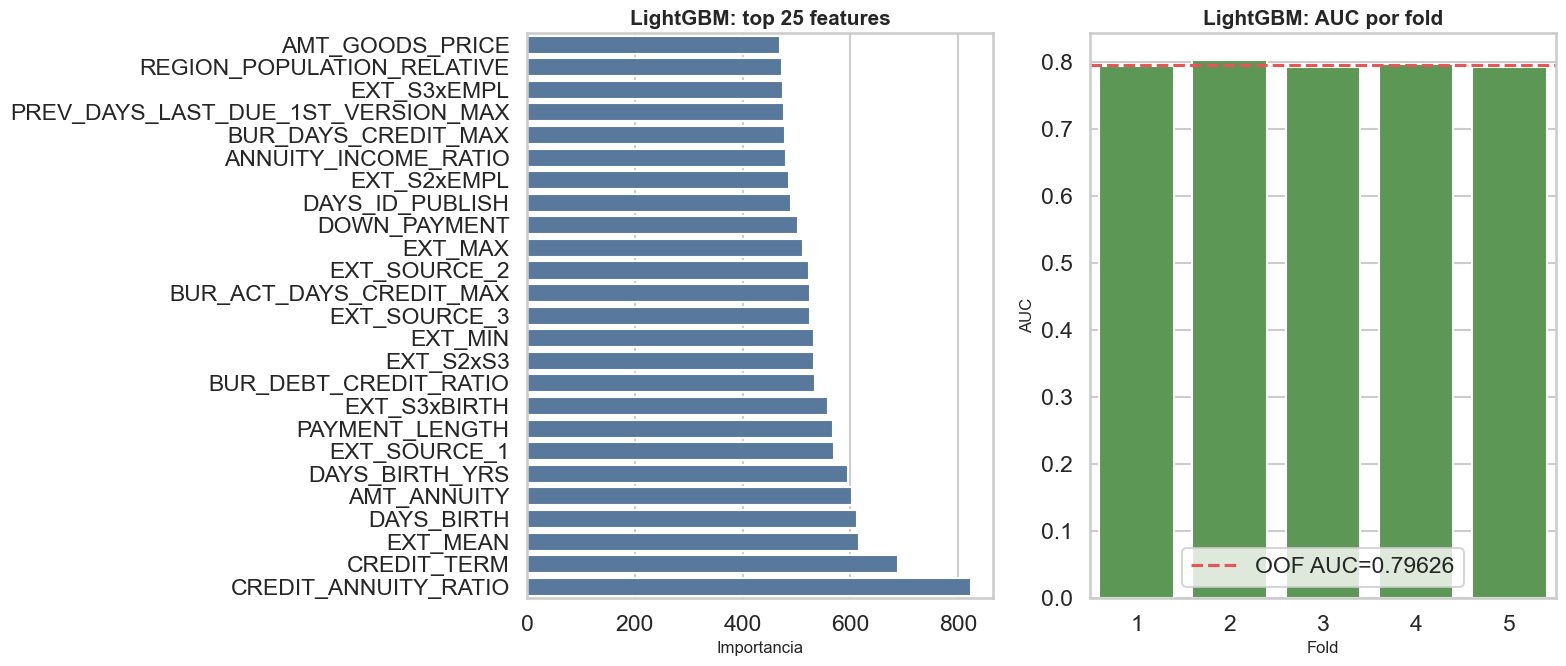

Figura guardada en: results/extras/20260625_092941/figures/lightgbm_oof_importance.png


In [7]:
if lgb_result is not None:
    top_lgb = reporter.top_features(lgb_result, n=25)
    display(top_lgb)
    display(reporter.by_source(lgb_result))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.barplot(
        data=top_lgb.iloc[::-1],
        x="importance",
        y="feature",
        ax=axes[0],
        color="#4C78A8",
    )
    axes[0].set_title("LightGBM: top 25 features")
    axes[0].set_xlabel("Importancia")
    axes[0].set_ylabel("")

    fold_frame = pd.DataFrame(
        {"fold": np.arange(1, len(lgb_result.fold_aucs) + 1), "auc": lgb_result.fold_aucs}
    )
    sns.barplot(data=fold_frame, x="fold", y="auc", ax=axes[1], color="#54A24B")
    axes[1].axhline(lgb_result.oof_auc, color="#E45756", linestyle="--", label=f"OOF AUC={lgb_result.oof_auc:.5f}")
    axes[1].set_title("LightGBM: AUC por fold")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("AUC")
    axes[1].legend()

    fig.tight_layout()
    fig_path = paths.figures_dir / "lightgbm_oof_importance.png"
    fig.savefig(fig_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Figura guardada en:", paths.to_project_relative(fig_path))

## <font color="#0099CC">**5. XGBoost relacional**</font>

XGBoost pertenece a la misma familia general que LightGBM: *gradient boosting* sobre árboles. Ambos modelos construyen predictores de forma secuencial, pero difieren en regularización, estrategia de crecimiento, manejo interno de particiones y coste computacional.

Incluir XGBoost sirve como contraste independiente. Si LightGBM y XGBoost obtienen resultados cercanos sobre la misma matriz relacional, la conclusión es más robusta: la mejora viene principalmente de la información relacional y de la adecuación de los árboles a datos tabulares, no de una particularidad aislada de una librería.

Sus ventajas frente a redes densas en este contexto son claras: suelen requerir menos ajuste fino, toleran mejor valores ausentes y aprovechan interacciones irregulares entre variables. Su inconveniente es que, en esta versión, no integran de forma nativa los componentes de confiabilidad del MVP: penalización FAIR, análisis Pareto e incertidumbre.

In [ ]:

xgb_result = None

if RUN_XGBOOST:
    xgb_runner = XGBoostOOFRunner(config=gbm_config, artifacts=paths)
    xgb_result = xgb_runner.run(X_train, y_train, X_test)
    model_results.append(xgb_result)
    display(pd.DataFrame([xgb_result.metrics_dict()]).drop(columns=["params", "fold_aucs"]))
else:
    xgb_pending = pd.DataFrame(
        [
            {
                "experimento": "XGBoost relacional",
                "estado": "pendiente de ejecución",
                "nota": "Se incorporará a la comparación global cuando se ejecute en este notebook.",
            }
        ]
    )
    display(xgb_pending)


## <font color="#0099CC">**6. Comparación global de experimentos**</font>

La comparación final reúne experimentos con objetivos distintos. Por eso no se interpreta como una carrera simple por el mayor AUC. El MVP base y el MVP FAIR representan el cumplimiento obligatorio con 12 variables. El modelo de 42 variables mide el efecto de ampliar la tabla principal. LightGBM y XGBoost miden el techo predictivo al usar información relacional completa. La variante de coste cuadrática de Javi estudia sensibilidad del aprendizaje justo.

La tabla separa familia de modelo, features usadas, fuentes de datos, objetivo, tipo de métrica y estado. Así el evaluador puede entender qué se está comparando y qué no. Un modelo con mayor AUC puede ser menos completo desde el punto de vista de confiabilidad; por eso el MVP FAIR sigue siendo el modelo principal del taller y los extras explican rutas de mejora o análisis adicionales.

In [ ]:

def safe_float(value):
    if value is None or pd.isna(value):
        return np.nan
    return float(value)


def add_experiment_row(
    rows,
    *,
    experimento,
    familia_modelo,
    features_usadas,
    fuentes_datos,
    objetivo,
    auc=np.nan,
    metrica_auc="pendiente",
    abs_rho=np.nan,
    dpd=np.nan,
    eod=np.nan,
    incertidumbre="No evaluada",
    estado="pendiente",
    origen_resultado="",
    comentario="",
):
    rows.append(
        {
            "experimento": experimento,
            "familia_modelo": familia_modelo,
            "features_usadas": features_usadas,
            "fuentes_datos": fuentes_datos,
            "objetivo": objetivo,
            "auc": safe_float(auc),
            "métrica_auc": metrica_auc,
            "abs_rho": safe_float(abs_rho),
            "dpd": safe_float(dpd),
            "eod": safe_float(eod),
            "incertidumbre": incertidumbre,
            "estado": estado,
            "origen_resultado": origen_resultado,
            "comentario": comentario,
        }
    )


comparison_rows = []
project_tables = PROJECT_ROOT / "results" / "tables"

mvp_path = project_tables / "test_results_base_vs_fair.csv"
if mvp_path.exists():
    mvp_results = pd.read_csv(mvp_path)
    base_rows = mvp_results[mvp_results["modelo"].str.contains("Base", case=False, na=False)]
    fair_rows = mvp_results[mvp_results["modelo"].str.contains("FAIR", case=False, na=False)]

    if not base_rows.empty:
        base = base_rows.iloc[0]
        add_experiment_row(
            comparison_rows,
            experimento="MVP 12 features - Base",
            familia_modelo="Red neuronal densa",
            features_usadas="12 variables del MVP",
            fuentes_datos="application_train reducido",
            objetivo="Baseline predictivo obligatorio",
            auc=base["auc"],
            metrica_auc="test AUC",
            abs_rho=base["abs_rho"],
            dpd=base["dpd"],
            eod=base["eod"],
            incertidumbre="No",
            estado="ejecutado",
            origen_resultado=paths.to_project_relative(mvp_path),
            comentario="Punto de partida para medir el coste predictivo de imponer fairness.",
        )

    if not fair_rows.empty:
        fair = fair_rows.iloc[0]
        add_experiment_row(
            comparison_rows,
            experimento="MVP 12 features - FAIR",
            familia_modelo="Red neuronal con penalización FAIR",
            features_usadas="12 variables del MVP",
            fuentes_datos="application_train reducido",
            objetivo="Modelo principal confiable del taller",
            auc=fair["auc"],
            metrica_auc="test AUC",
            abs_rho=fair["abs_rho"],
            dpd=fair["dpd"],
            eod=fair["eod"],
            incertidumbre="Sí, M2 en el notebook MVP",
            estado="ejecutado",
            origen_resultado=paths.to_project_relative(mvp_path),
            comentario="Reduce la dependencia con género a cambio de una pérdida pequeña de AUC.",
        )
else:
    add_experiment_row(
        comparison_rows,
        experimento="MVP 12 features - Base/FAIR",
        familia_modelo="Red neuronal",
        features_usadas="12 variables del MVP",
        fuentes_datos="application_train reducido",
        objetivo="Referencia obligatoria",
        estado="pendiente",
        comentario="No se encontró la tabla test_results_base_vs_fair.csv.",
    )

feature_42_candidates = [
    paths.tables_dir / "feature_ablation_12_vs_42_summary.csv",
    project_tables / "feature_ablation_12_vs_42_audited.csv",
]
features_42_path = next((path for path in feature_42_candidates if path.exists()), None)
if features_42_path is not None:
    features_42 = pd.read_csv(features_42_path)
    estado_42 = (
        "generado en este notebook"
        if features_42_path.parent == paths.tables_dir
        else "artefacto del proyecto"
    )
    best_42 = features_42.sort_values("auc_42_features", ascending=False).iloc[0]
    add_experiment_row(
        comparison_rows,
        experimento="Red neuronal 42 features",
        familia_modelo="Red neuronal extendida",
        features_usadas="42 variables de application_train",
        fuentes_datos="application_train ampliado",
        objetivo="Medir el efecto de ampliar variables sin usar tablas relacionales",
        auc=best_42["auc_42_features"],
        metrica_auc="AUC auditado 42 features",
        incertidumbre="No evaluada en esta tabla",
        estado=estado_42,
        origen_resultado=paths.to_project_relative(features_42_path),
        comentario=(
            f"Mejor fila: {best_42['model']}; "
            f"ganancia frente a 12 features: {best_42['auc_gain_42_vs_12']:.4f}."
        ),
    )
else:
    add_experiment_row(
        comparison_rows,
        experimento="Red neuronal 42 features",
        familia_modelo="Red neuronal extendida",
        features_usadas="42 variables de application_train",
        fuentes_datos="application_train ampliado",
        objetivo="Medir el efecto de ampliar variables sin usar tablas relacionales",
        estado="pendiente",
        comentario="Pendiente de generar o localizar el artefacto de 42 features.",
    )

current_results = list(globals().get("model_results", []))

def find_result(fragment):
    fragment = fragment.lower()
    for result in current_results:
        if fragment in result.model_name.lower():
            return result
    return None

relational_feature_count = X_train.shape[1] if "X_train" in globals() else np.nan
relational_sources = "application + bureau + previous_application + installments + POS_CASH + credit_card"

lgb_result_for_table = find_result("lightgbm")
if lgb_result_for_table is not None:
    add_experiment_row(
        comparison_rows,
        experimento="LightGBM relacional",
        familia_modelo="Gradient boosting",
        features_usadas=f"{relational_feature_count} features relacionales",
        fuentes_datos=relational_sources,
        objetivo="Techo predictivo tabular con historial relacional",
        auc=lgb_result_for_table.oof_auc,
        metrica_auc="OOF AUC",
        incertidumbre="No",
        estado="ejecutado en este notebook",
        origen_resultado=paths.to_project_relative(paths.run_dir),
        comentario="Modelo tabular fuerte; no incorpora penalización FAIR explícita.",
    )
else:
    add_experiment_row(
        comparison_rows,
        experimento="LightGBM relacional",
        familia_modelo="Gradient boosting",
        features_usadas="features relacionales completas",
        fuentes_datos=relational_sources,
        objetivo="Techo predictivo tabular con historial relacional",
        estado="pendiente",
        comentario="Se añadirá automáticamente cuando exista lgb_result en model_results.",
    )

xgb_result_for_table = find_result("xgboost")
if xgb_result_for_table is not None:
    add_experiment_row(
        comparison_rows,
        experimento="XGBoost relacional",
        familia_modelo="Gradient boosting",
        features_usadas=f"{relational_feature_count} features relacionales",
        fuentes_datos=relational_sources,
        objetivo="Contraste independiente de boosting sobre la misma matriz relacional",
        auc=xgb_result_for_table.oof_auc,
        metrica_auc="OOF AUC",
        incertidumbre="No",
        estado="ejecutado en este notebook",
        origen_resultado=paths.to_project_relative(paths.run_dir),
        comentario="Comprueba si la mejora se mantiene con otra implementación de boosting.",
    )
else:
    add_experiment_row(
        comparison_rows,
        experimento="XGBoost relacional",
        familia_modelo="Gradient boosting",
        features_usadas="features relacionales completas",
        fuentes_datos=relational_sources,
        objetivo="Contraste independiente de boosting sobre la misma matriz relacional",
        estado="pendiente",
        comentario="Pendiente de ejecución; no se sustituye por una referencia fija.",
    )

squared_dp_path = project_tables / "squared_dp_sweep_results.csv"
if squared_dp_path.exists():
    squared_dp = pd.read_csv(squared_dp_path)
    best_squared = squared_dp.sort_values(
        ["test_abs_rho", "test_dpd", "test_auc"],
        ascending=[True, True, False],
    ).iloc[0]
    add_experiment_row(
        comparison_rows,
        experimento="FAIR cuadrático",
        familia_modelo="Red neuronal con coste FAIR cuadrático",
        features_usadas="features del experimento FAIR cuadrático",
        fuentes_datos="application_train",
        objetivo="Sensibilidad de la función de coste de fairness",
        auc=best_squared["test_auc"],
        metrica_auc="test AUC",
        abs_rho=best_squared["test_abs_rho"],
        dpd=best_squared["test_dpd"],
        eod=best_squared["test_eod"],
        incertidumbre="No evaluada en esta tabla",
        estado="artefacto del proyecto",
        origen_resultado=paths.to_project_relative(squared_dp_path),
        comentario=(
            f"Mejor contraste por fairness: alpha={best_squared['alpha']}. "
            "No compite como techo predictivo; analiza la forma de penalizar la dependencia."
        ),
    )
else:
    add_experiment_row(
        comparison_rows,
        experimento="FAIR cuadrático",
        familia_modelo="Red neuronal con coste FAIR cuadrático",
        features_usadas="pendiente",
        fuentes_datos="application_train",
        objetivo="Sensibilidad de la función de coste de fairness",
        estado="pendiente",
        comentario="Pendiente de implementar o ejecutar en este flujo de extras.",
    )

comparison = pd.DataFrame(comparison_rows)
ordered_columns = [
    "experimento",
    "familia_modelo",
    "features_usadas",
    "fuentes_datos",
    "objetivo",
    "auc",
    "métrica_auc",
    "abs_rho",
    "dpd",
    "eod",
    "incertidumbre",
    "estado",
    "origen_resultado",
    "comentario",
]
comparison = comparison.loc[:, ordered_columns]
display(comparison)

comparison_csv = paths.tables_dir / "global_experiment_comparison.csv"
comparison_csv.resolve().relative_to(paths.run_dir.resolve())
comparison.to_csv(comparison_csv, index=False)

plot_data = comparison[comparison["auc"].notna()].copy()
fig, ax = plt.subplots(figsize=(12, 6.5))
sns.barplot(
    data=plot_data,
    x="auc",
    y="experimento",
    hue="familia_modelo",
    dodge=False,
    ax=ax,
)
ax.set_title("Comparación global de AUC por experimento")
ax.set_xlabel("AUC")
ax.set_ylabel("")
ax.set_xlim(max(0.45, plot_data["auc"].min() - 0.03), max(0.82, plot_data["auc"].max() + 0.02))
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
comparison_path = paths.figures_dir / "global_experiment_comparison.png"
comparison_path.resolve().relative_to(paths.run_dir.resolve())
fig.savefig(comparison_path, dpi=220, bbox_inches="tight")
plt.show()

print("Tabla guardada en:", paths.to_project_relative(comparison_csv))
print("Figura guardada en:", paths.to_project_relative(comparison_path))


## <font color="#0099CC">**7. Artefactos y conclusión defendible**</font>

El cierre registra qué se ha ejecutado y dónde quedan los resultados. Las tablas, predicciones, importancias y figuras se guardan dentro de `results/extras/<run_id>/`. Esta regla mantiene intactos los resultados del MVP y permite revisar los extras sin mezclar evidencias.

La conclusión esperada es doble. El MVP resuelve el objetivo confiable del taller: fairness, Pareto e incertidumbre. Los extras muestran que el rendimiento predictivo puede subir al usar más variables, más historial financiero y modelos tabulares especializados. Ambas ideas son compatibles y fortalecen la defensa del proyecto.

In [ ]:

manifest_rows = []
for result in globals().get("model_results", []):
    manifest_rows.append(
        {
            "model_name": result.model_name,
            "oof_auc": result.oof_auc,
            "oof_accuracy": result.oof_accuracy,
            "fold_auc_mean": result.fold_auc_mean,
            "fold_auc_std": result.fold_auc_std,
            "n_features": X_train.shape[1],
            "n_train_rows": X_train.shape[0],
        }
    )

manifest_path = None
if manifest_rows:
    manifest_path = write_extras_manifest(paths, rows=manifest_rows)

comparison_csv = paths.tables_dir / "global_experiment_comparison.csv"
artifact_rows = [
    {"artefacto": "Run extras", "ruta": paths.to_project_relative(paths.run_dir)},
    {"artefacto": "Tablas", "ruta": paths.to_project_relative(paths.tables_dir)},
    {"artefacto": "Predicciones", "ruta": paths.to_project_relative(paths.predictions_dir)},
    {"artefacto": "Figuras", "ruta": paths.to_project_relative(paths.figures_dir)},
]
if comparison_csv.exists():
    artifact_rows.append({"artefacto": "Comparación global", "ruta": paths.to_project_relative(comparison_csv)})
if manifest_path is not None:
    artifact_rows.append({"artefacto": "Manifest", "ruta": paths.to_project_relative(manifest_path)})

display(pd.DataFrame(artifact_rows))

print("Resumen defendible:")
print("- El MVP no se toca: sigue siendo el entregable obligatorio y confiable.")
print("- La comparación separa modelos de 12 variables, 42 variables, boosting relacional y coste FAIR cuadrático.")
print("- LightGBM y XGBoost miden techo predictivo tabular; no sustituyen el análisis FAIR del MVP.")
print("- Los artefactos de este notebook quedan aislados en:", paths.run_dir)
